## Hälsostudie
### Grundläggande analys och statistik

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(42)
df = pd.read_csv("health_study_dataset.csv")


#### Räkna ut medel, median, min och max för: age, weight, height, systolic_bp och cholesterol

In [2]:
chosen_columns = df[["age", "weight", "height", "systolic_bp", "cholesterol"]]
statistics_of_columns = pd.DataFrame({"Medel": chosen_columns.mean(), "Median": chosen_columns.median(),
                                      "Min": chosen_columns.min(), "Max": chosen_columns.max()})

statistics_of_columns

,Medel,Median,Min,Max
age,49.426250,50.00,18.0,90.00
weight,73.413000,73.20,33.7,114.40
height,171.849250,171.35,144.4,200.40
systolic_bp,149.178625,149.40,106.8,185.90
cholesterol,4.929150,4.97,2.5,7.88


#### Grafer över värden

- Histogram över blodtryck
- Stapeldiagram över andelen rökare
- Scatter för kolesterol fördelat över åldrar

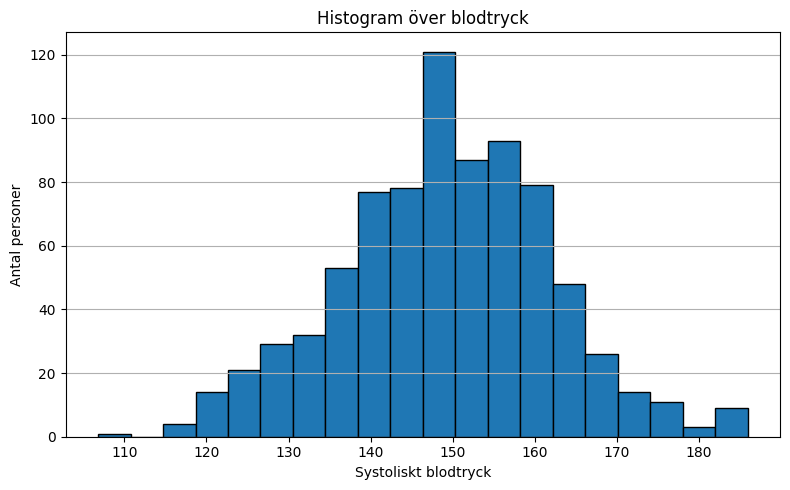

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax = df["systolic_bp"].dropna().plot(kind="hist", bins=20, edgecolor="black")
ax.set_title("Histogram över blodtryck")
ax.set_xlabel("Systoliskt blodtryck")
ax.set_ylabel("Antal personer")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

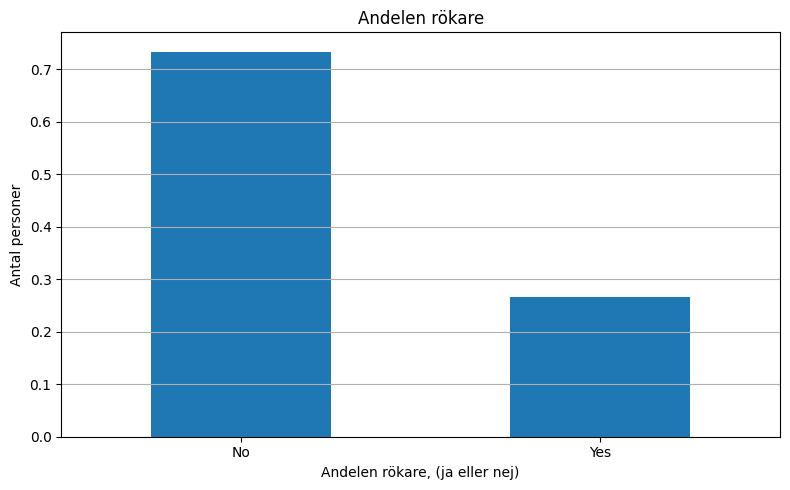

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
amount_of_smokers = df["smoker"].value_counts(normalize=True).plot(kind="bar")
ax.set_title("Andelen rökare")
ax.set_xlabel("Andelen rökare, (ja eller nej)")
ax.set_ylabel("Antal personer")
ax.grid(True, axis="y")
ax.set_xticklabels(ax.get_xticklabels(), rotation=360)
plt.tight_layout()
plt.show()


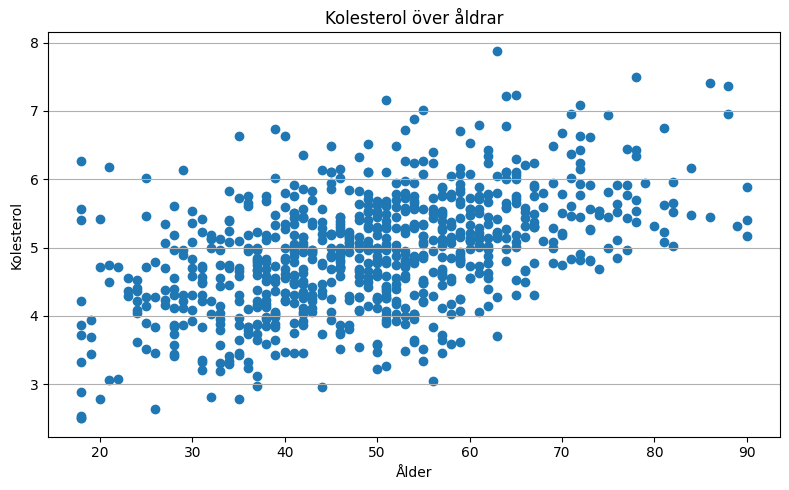

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["age"], df["cholesterol"])
ax.set_title("Kolesterol över åldrar")
ax.set_xlabel("Ålder")
ax.set_ylabel("Kolesterol")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

## Simulering

#### Beräkna andelen personer i datasetet som har sjukdomen

In [6]:
disease_amount = df["disease"].mean()
print(f"Antal personer som har sjukdomen:{disease_amount:.2f}")

simuleringar = [np.random.choice([0, 1], size=1000, p=[1 - disease_amount, disease_amount]).mean() for _ in range(1000)]
print(f"Medel av 1000 simuleringar: {np.mean(simuleringar):.4f}")
print(f"Standardavvikelse: {np.std(simuleringar):.4f}")

Antal personer som har sjukdomen:0.06
Medel av 1000 simuleringar: 0.0591
Standardavvikelse: 0.0077


Antal personer med sjukdomen: **6% av personerna i datasetet har sjukdomen**
Medelvärdet av 1000 simuleringar (1000 personer, upprepat 1000 gånger): ca 0.059
- Medel av simuleringarna: 0.0591 **ca 5.91%**
- Standardavvikelse: 0.0077, **ca 0.77 %-enheter**

Det simulerade medelvärdet (5.86%) ligger mycket nära den observerade andelen (6.00%)

### **Konfidensintervall**

- Beräkna ett konfidensintervall för medelvärdet av systoliskt blodtryck (systolic_bp) 
    - Använde bootstrap metoden för beräkning

In [7]:
data = df["systolic_bp"]
num_samples = 10_000

bootstrap_means = np.zeros(num_samples)
for i in range(num_samples):
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_mean = np.mean(bootstrap_sample)
    bootstrap_means[i] = bootstrap_mean
ci_lower, ci_higher = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"95% konfidensintervall (bootstrap): [{ci_lower:.2f}, {ci_higher:.2f}]")

95% konfidensintervall (bootstrap): [148.28, 150.06]


- Det genomsnittliga blodtrycket med 95% sannolikhet ligger ungefär mellan 148 mmHg och 150 mmHg

## **Hypotesprövning**

### Har rökare högre medel-blodtryck än icke-rökare?
- För att testa hypotesen har jag använt mig av bootstrap metoden.

In [8]:
smokers = df[df['smoker']=='Yes']['systolic_bp']
nonsmokers = df[df['smoker']=='No']['systolic_bp']

n_boot = 10_000
obs_diff = smokers.mean() - nonsmokers.mean()

boot_diffs = np.empty(n_boot)
for i in range(n_boot):
    A_group = np.random.choice(smokers, size=len(smokers), replace=True)
    B_group = np.random.choice(nonsmokers, size=len(nonsmokers), replace=True)
    boot_diffs[i] = B_group.mean() - A_group.mean()

p_boot = np.mean(boot_diffs <= 0)

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print(obs_diff)
print(p_boot)
print((ci_low, ci_high))

0.47190136846063524
0.6773
(np.float64(-2.5661417968343656), np.float64(1.5978079036398949))


### **Resultat**

- Skillnaden i medelvärde mellan rökare och ickerökare är: **0.47 mmHg**
- P-värdet är: **ca 0.67%**
- 95% konfidensintervall ligger runt: **-2.56 och 1.59**

P-värdet är större än 0.05 och konfidensintervallet inkluderar 0, det går därmed inte att se någon större skillnad i medelblodtryck mellan rökare och icke-rökare baserat på datan från datasetet. 

#### Slutsats
Hypotesen att rökare skulle ha högre blodtryck än icke-rökare går inte stödja med den data som finns i datasetet.